In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN, KMeans
from kneed import KneeLocator

sns.set(rc={'figure.figsize':(11.7,8.27)})

# List of training columns
train_cols = ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants','AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies','HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice','BMI']
# train_cols = [ 'Diabetes', 'BloodPressureProblems', 'AnyTransplants','AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies','HistoryOfCancerInFamily', 'NumberOfMajorSurgeries','BMI']


## Loading the dataset

In [102]:
data = pd.read_csv('Data_Ergebnisse_neu.csv',index_col='ID')
data = data.reset_index(drop=True)

In [72]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Choose the number of clusters (K)
k = 500

# Fit KNN model
knn = NearestNeighbors(n_neighbors=k)
knn.fit(data)

# Find K nearest neighbors for each data point
distances, indices = knn.kneighbors(data)

# Assign clusters based on majority vote of neighbors for each data point
cluster_assignments = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=1, arr=indices)

# Print data points with their cluster IDs
# for i, cluster_id in enumerate(cluster_assignments):
#     print(f"Data point {i+1} belongs to Cluster {cluster_id}")

data['KNN_Clusters'] = cluster_assignments

In [90]:
for i in range(len(indices)):
    counts = {}
    for neighbor in indices[5]:
        if neighbor in counts:
            counts[neighbor] += 1
        else:
            counts[neighbor] = 1
    print(counts)
    break
max(counts, key=counts.get)

{5: 1, 887: 1, 28: 1, 415: 1, 413: 1, 754: 1, 330: 1, 962: 1, 273: 1, 96: 1, 902: 1, 178: 1, 431: 1, 721: 1, 965: 1, 15: 1, 899: 1, 846: 1, 421: 1, 60: 1, 105: 1, 949: 1, 882: 1, 180: 1, 122: 1, 63: 1, 635: 1, 864: 1, 113: 1, 368: 1, 411: 1, 972: 1, 511: 1, 419: 1, 171: 1, 406: 1, 2: 1, 347: 1, 379: 1, 790: 1, 55: 1, 853: 1, 872: 1, 391: 1, 930: 1, 475: 1, 939: 1, 576: 1, 710: 1, 879: 1, 913: 1, 898: 1, 589: 1, 873: 1, 967: 1, 904: 1, 944: 1, 50: 1, 77: 1, 639: 1, 630: 1, 534: 1, 778: 1, 376: 1, 975: 1, 861: 1, 495: 1, 514: 1, 893: 1, 515: 1, 587: 1, 375: 1, 889: 1, 946: 1, 772: 1, 794: 1, 255: 1, 591: 1, 607: 1, 654: 1, 408: 1, 941: 1, 577: 1, 467: 1, 912: 1, 845: 1, 470: 1, 17: 1, 182: 1, 579: 1, 891: 1, 905: 1, 815: 1, 292: 1, 760: 1, 487: 1, 970: 1, 623: 1, 777: 1, 918: 1, 344: 1, 312: 1, 753: 1, 529: 1, 305: 1, 832: 1, 278: 1, 523: 1, 803: 1, 176: 1, 443: 1, 703: 1, 36: 1, 299: 1, 8: 1, 743: 1, 201: 1, 664: 1, 919: 1, 23: 1, 168: 1, 356: 1, 655: 1, 472: 1, 653: 1, 657: 1, 124: 1, 

5

In [86]:
# silhouette_score(data[train_cols], cluster_assignments)
set(indices[1]).__len__()

500

# KNN

In [92]:
k = 3 #10 # 3 Number of neighbors (k)
nbrs = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(data[train_cols])

In [93]:
distances, indices = nbrs.kneighbors(data[train_cols])

data['knn_distances'] = np.mean(distances, axis=1) # k-NN distances for each point
data['neighbors'] = indices.tolist()
data['neighbors_dist'] = distances.tolist()
threshold = np.mean(data['knn_distances']) + 2 * np.std(data['knn_distances']) # Mean + 2 * std

anomalies = data['knn_distances'] > threshold
data['Is Anomaly'] = anomalies
anomali_data_knn = data[data['Is Anomaly'] == True]

(array([789., 136.,  29.,   5.,   4.,   5.,   4.,   1.,   2.,   1.]),
 array([ 1.19903527,  4.53728034,  7.87552542, 11.21377049, 14.55201556,
        17.89026063, 21.22850571, 24.56675078, 27.90499585, 31.24324093,
        34.581486  ]),
 <BarContainer object of 10 artists>)

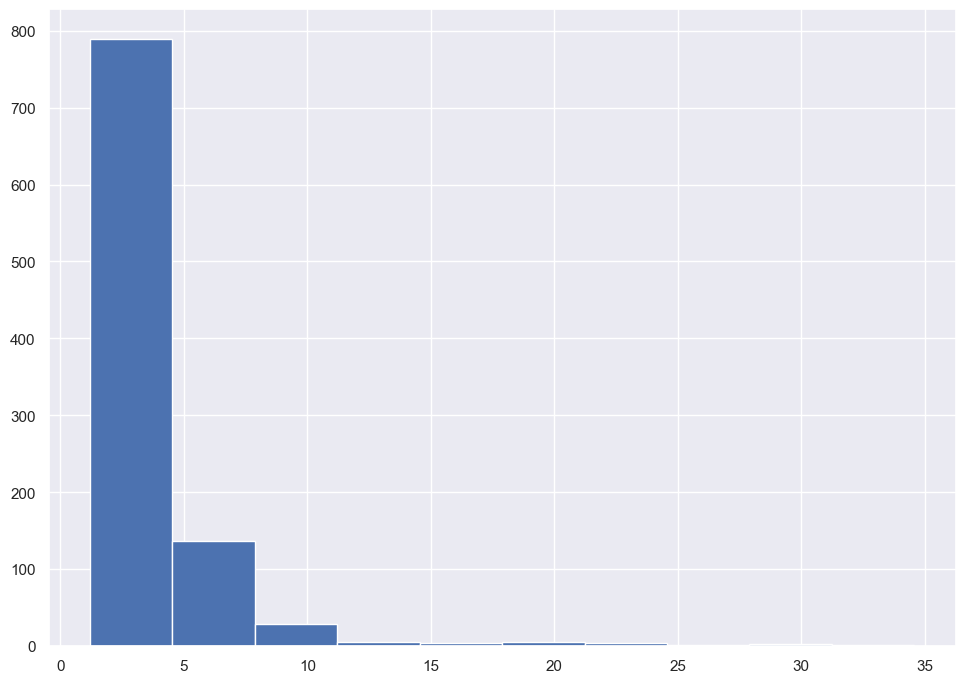

In [100]:
plt.hist(data[data['Is Anomaly'] == False]['knn_distances'],bins=10)

### Threshold value (Mean + 2 * std)

In [ ]:
threshold

# Boxplot of the KNN distances

Text(0.5, 1.0, 'Box plot with Outliers')

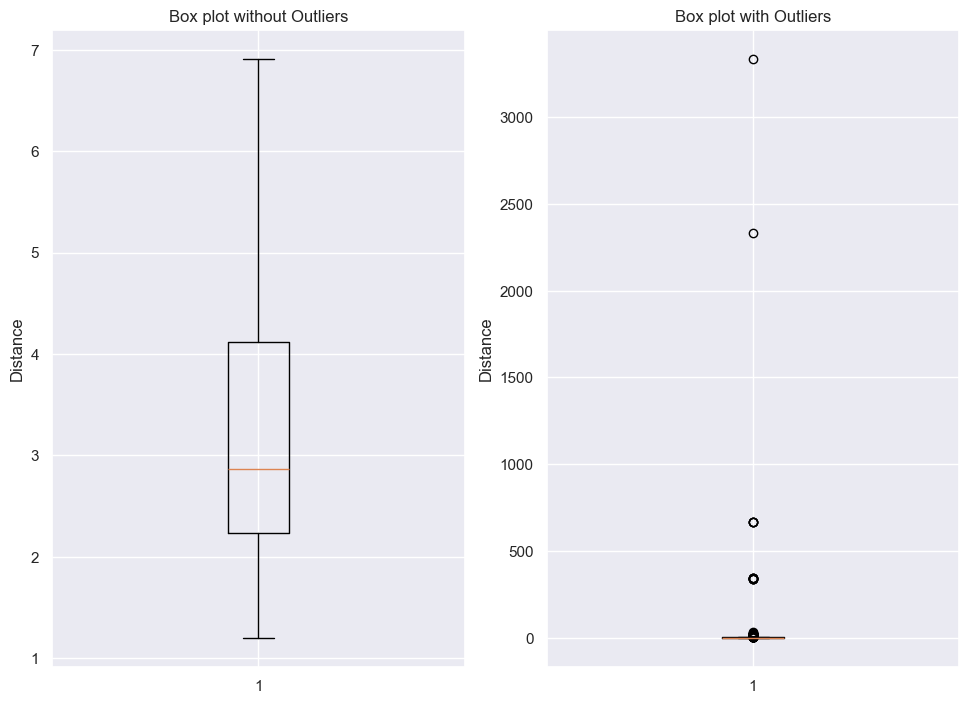

In [5]:
plt.subplot(1, 2, 1)
plt.boxplot(data['knn_distances'],showfliers=False)
plt.ylabel('Distance')
plt.title('Box plot without Outliers')

plt.subplot(1, 2, 2)
plt.boxplot(data['knn_distances'])
plt.ylabel('Distance')
plt.title('Box plot with Outliers')

# KMeans

In [24]:
from k_means_constrained import KMeansConstrained

best_score = -1
best_clusters = 2  # Start with 2 clusters

range_of_clusters = range(2, 100)

for k in range_of_clusters:
    # kmeans = KMeans(n_clusters=k, random_state=0,n_init='auto')
    kmeans = KMeansConstrained(n_clusters=k, size_min=3,n_jobs=-1)
    kmeans.fit(data[train_cols])
    labels = kmeans.labels_
    score = silhouette_score(data[train_cols], labels)
    
    if score > best_score:
        best_score = score
        best_clusters = k
        best_model = kmeans

print(f"Best number of clusters: {best_clusters}")
print(f"Best silhouette score: {best_score}")

Best number of clusters: 19
Best silhouette score: 0.9575507214772693


In [7]:
data['KMeans_Cluster'] = best_model.labels_

### Idea: I can also compute an average distance in each cluster and if the distance to the center of the cluster is higher then the 90% quantile of the other points within the same cluster will be marked as outliers

In [8]:
# Marking Clusters having less then 3 points as Outliers
for i in set(best_model.labels_):
    if len(data[data['KMeans_Cluster'] == i]) < 3:
        print(i, end=', ')
        data.loc[data['KMeans_Cluster'] == i,'KMeans_Anomaly'] = True

In [9]:
# Euclidean distance between each data point and its cluster center
data['Distance to Center'] = np.linalg.norm(data[train_cols] - best_model.cluster_centers_[best_model.labels_], axis=1)

threshold = data['Distance to Center'].quantile(0.95) 
data['KMeans_Anomaly'] = data['Distance to Center'] > threshold
anomali_data_kMeans = data[data['KMeans_Anomaly'] == True]

### Threshold value (Mean + 2 * std)

In [12]:
threshold 

38.67612605436447

In [13]:
test_data = data[data['KMeans_Anomaly'] != True ]
silhouette_avg = silhouette_score(test_data[train_cols], test_data['KMeans_Cluster'])
print(f"Silhouette Score without outliers: {silhouette_avg}")

Silhouette Score without outliers: 0.978809506077406


In [14]:
silhouette_avg = silhouette_score(data[train_cols], data['KMeans_Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9576754351748862


# DBSCAN

MinPts: To derive the minimum value for MinPts, a rule of thumb is to set it to be greater than or equal to the number of dimensions D in the data set, i.e., MinPts ≥ D + 1

To choose the value of ε, a k-distance graph is plotted by ordering the distance to the k=MinPts-1 nearest neighbor from the largest to the smallest value.

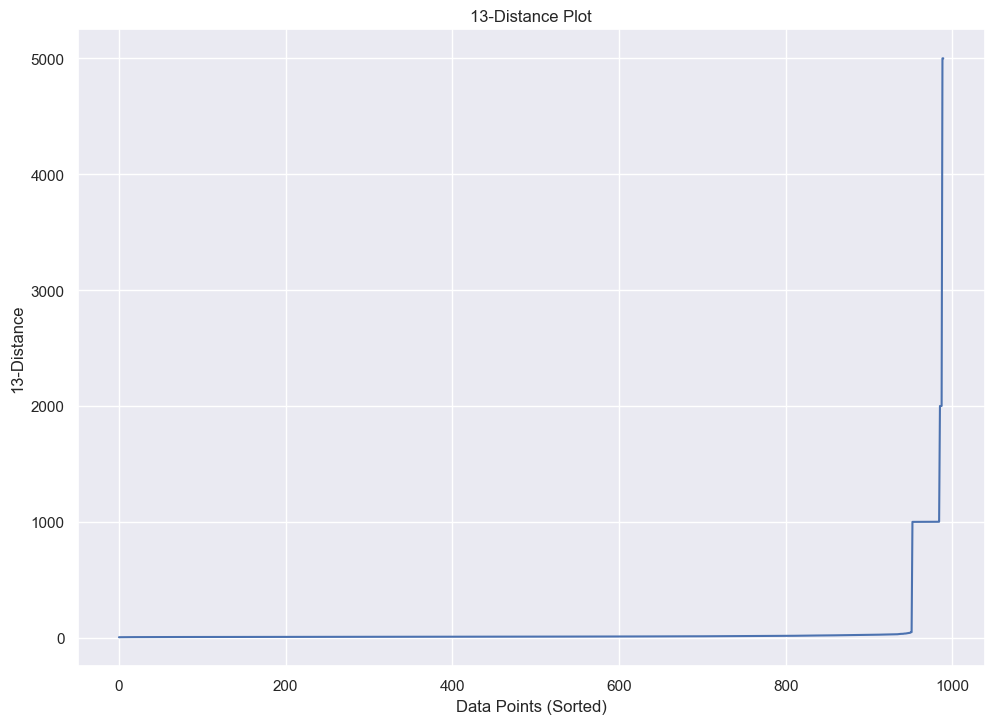

In [25]:
k =  len(train_cols) + 1 # 

# Calculate the distances to the k-th nearest neighbors for each data point
nbrs = NearestNeighbors(n_neighbors=k).fit(data[train_cols])
distances, _ = nbrs.kneighbors(data[train_cols])
k_distances = np.sort(distances[:, -1]) 

plt.plot(range(len(data)), k_distances)
plt.xlabel('Data Points (Sorted)')
plt.ylabel(f'{k}-Distance')
plt.title(f'{k}-Distance Plot')

plt.show()

### Create a for loop that will interate over diffrenet values of S, and min_samples

In [26]:
S = [1,2,3,5,10,15,20]
best_silhouette_score = -1
dataset_size = len(data[train_cols])
min_samples_fraction = 0.005  # 0.5% of the dataset size
min_samples_range = range(int(dataset_size * min_samples_fraction), int(dataset_size * 0.05))  # Range: 0.5% to 5% of dataset size

In [27]:
for s in S:
    kneedle = KneeLocator(range(len(data)), k_distances, curve="convex",S=s)
    # print(kneedle.elbow_y)
    eps = round(kneedle.elbow_y, 0)  
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=kneedle.elbow_y, min_samples=min_samples)
        dbscan.fit(data[train_cols])
        silhouette_avg = silhouette_score(data[train_cols], dbscan.labels_)
        # print(silhouette_avg)
        if best_silhouette_score < silhouette_avg:
            best_silhouette_score = silhouette_avg
            best_model_DBSCAN = dbscan
            best_s = s
            best_eps = eps
            best_min_samples = min_samples

print(f'Best Silhouette Score is {best_silhouette_score} with S= {best_s}, eps= {best_eps} and min_samples= {best_min_samples}')


Best Silhouette Score is 0.6209593315681042 with S= 2, eps= 1001.0 and min_samples= 46


### Trying to fit DBSCAN with manually determined parameters

In [35]:
eps = 1000  # Maximum distance between two samples to be considered as in the same neighborhood
min_samples = 6  # Minimum number of samples in a neighborhood for a data point to be considered a core point

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(data[train_cols])
data['DBSCAN_Cluster'] = dbscan.labels_
anomalies = data['DBSCAN_Cluster'] == -1
data['DBSCAN_outlier'] = anomalies
anomali_data_DBSCAN = data[data['DBSCAN_outlier'] == True]

In [36]:
anomali_data = data[data['DBSCAN_outlier'] == True]
silhouette_avg = silhouette_score(data[train_cols], data['DBSCAN_Cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9272278920556629


In [37]:
test_data = data[data['DBSCAN_outlier'] == False]
silhouette_avg = silhouette_score(test_data[train_cols], test_data['DBSCAN_Cluster'])
print(f"Silhouette Score without outliers : {silhouette_avg}")

Silhouette Score without outliers : 0.9856740866503588


# HDBSCAN

In [28]:
from hdbscan import HDBSCAN
hdbscan = HDBSCAN(min_cluster_size=5, min_samples = 10)
# hdbscan = HDBSCAN(min_samples = 10)

data['HDBSCAN_cluster'] = hdbscan.fit_predict(data[train_cols])
h = hdbscan.fit(data[train_cols])
data['HDBSCAN_cluster_outlier_score'] = h.outlier_scores_
anomali_data_HDBSCAN = data[data['HDBSCAN_cluster'] ==  -1]

In [39]:
silhouette_avg = silhouette_score(data[train_cols], data['HDBSCAN_cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.9348395523152033


In [40]:
test_data = data[data['HDBSCAN_cluster'] != -1]
silhouette_avg = silhouette_score(test_data[train_cols], test_data['HDBSCAN_cluster'])
print(f"Silhouette Score without outliers : {silhouette_avg}")

Silhouette Score without outliers : 0.9748233359237484


# Isolation Forest

In [103]:
from sklearn.ensemble import IsolationForest
model=IsolationForest(bootstrap= False,
 contamination= 'auto',
 max_features= 1.0,
 max_samples= 0.5,
 n_estimators= 50,
 n_jobs= None,
 random_state= 42,
 verbose= 0,
 warm_start= False)

# (n_estimators=10,max_samples='auto',contamination=float(0.03),random_state=0)

model.fit(data[train_cols])

print(model.get_params())

{'bootstrap': False, 'contamination': 'auto', 'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 50, 'n_jobs': None, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [104]:
data['IF_scores'] = model.decision_function(data[train_cols])

data['IF_anomaly_score'] = model.predict(data[train_cols])

anomali_data_IF = data[data['IF_anomaly_score']==-1]

The negative values returned by score_samples are indicative of the anomaly scores, where lower scores represent instances closer to the typical inliers (normal instances), and higher (less negative) scores suggest instances that are more likely to be outliers or anomalies according to the Isolation Forest model.

- Higher (less negative) scores: These scores indicate instances that required fewer splits to isolate in the Isolation Forest, suggesting they are more likely to be anomalies or outliers.
- Lower (more negative) scores: These scores denote instances that are closer to the normative behavior of the dataset and required more splits to isolate, implying they are more likely to be normal inliers.

Lower (more negative) scores imply greater typicality (inlier behavior), while higher (less negative) scores suggest greater likelihood of being anomalous (outlier behavior) within the dataset.

In [136]:
# # Define parameter combinations to iterate through
# param_combinations = [
#     {'n_estimators': 50, 'max_samples': 0.5},
#     {'n_estimators': 100, 'max_samples': 0.7},
#     {'n_estimators': 200, 'max_samples': 0.9}
#     # Add more parameter combinations as needed
#     {'n_estimators': 50, 'max_samples': 0.5,'max_features':1.0},
#     {'n_estimators': 100, 'max_samples': 0.7},
#     {'n_estimators': 200, 'max_samples': 0.9}
# ]

param_combinations = []

# Define parameter ranges
n_estimators_values = [10, 20, 30, 50, 70, 90, 100, 120, 150, 170, 190, 200]
max_samples_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
max_features_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

# Generate all combinations
for n_estimators in n_estimators_values:
    for max_samples in max_samples_values:
        for max_features in max_features_values:
            param_combinations.append({
                'n_estimators': n_estimators,
                'max_samples': max_samples,
                'max_features': max_features
            })

# Initialize variables to store best parameters and scores
best_score = float('-inf')
best_params = None

# Iterate through parameter combinations
for params in param_combinations:
    iso_forest = IsolationForest(**params, random_state=42)
    iso_forest.fit(data[train_cols])  # X_train is your training data
    
    # Evaluate using a custom metric (e.g., average anomaly score)
    # scores =   -iso_forest.score_samples(data[train_cols])  # score from a single tree
    scores = iso_forest.decision_function(data[train_cols])  # avg score of all the trees in the forest
    avg_score = np.mean(scores)
    
    # Update best parameters if the current score is better
    if avg_score > best_score:
        best_score = avg_score
        best_params = params

# Train the Isolation Forest with the best parameters on the entire training set
best_iso_forest = IsolationForest(**best_params, random_state=42)
best_iso_forest.fit(data[train_cols])  # X_train is your entire training data

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Best Parameters: {'n_estimators': 10, 'max_samples': 1.0, 'max_features': 0.5}
Best Score: 0.030664338946701664


In [114]:
data['anomaly_classification'] = best_iso_forest.predict(data[train_cols])

In [137]:
# plt.hist(scores)
data[data['anomaly_classification'] == -1]

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,IF_scores,IF_anomaly_score,anomaly_classification
6,33,0,0,0,0,150,54,0,0,0,21000,24.000000,0.024782,1,-1
12,24,0,0,0,0,178,57,1,0,1,15000,17.990153,-0.021083,-1,-1
14,18,0,0,1,0,150,76,0,0,1,15000,33.777778,-0.085071,-1,-1
19,21,0,1,0,0,186,97,0,0,0,15000,28.037923,-0.007667,-1,-1
24,53,0,1,0,0,151,97,0,1,1,35000,42.541994,-0.078973,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,47,1,1,0,0,158,73,1,0,1,39000,29.242109,0.000834,1,-1
986,26,0,0,0,0,182,120,0,0,0,43000,36.227509,-0.057141,-1,-1
987,24,1,1,1,0,163,103,1,0,1,24000,38.766984,-0.128784,-1,-1
988,62,1,0,1,1,171,94,1,0,1,17000,32.146643,-0.152203,-1,-1


In [126]:
from sklearn.ensemble import IsolationForest
model=IsolationForest(bootstrap= False,
 contamination= 'auto',
 max_features= 1.0,
 max_samples= 0.5,
 n_estimators= 50,
 random_state= 42)

# (n_estimators=10,max_samples='auto',contamination=float(0.03),random_state=0)

model.fit(data[train_cols])
data['IF_scores'] = model.decision_function(data[train_cols])

data['IF_anomaly_score'] = model.predict(data[train_cols])

anomali_data_IF = data[data['IF_anomaly_score']==-1]

So basically how model.predict() works as It will call  model.decision_function() internally which is just average of all the score_samples() for all the data points.

if the score is -ve this indicates that the point is likely to be an outlier while if the score is postivite it is likely to be an inlier. 


Greate the score in -ve direction i.e -10,-20 this inidicates the point to be an outlier.
Greate the score in +ve direction i.e 10,20 this inidicates the point to be an inlier.
if the score is very close to 0 that indicates that the points are not very isolated and may be more inliers.

{'whiskers': [<matplotlib.lines.Line2D at 0x175d1708810>,
 'caps': [<matplotlib.lines.Line2D at 0x175d1709ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x175d16ffe50>],
 'medians': [<matplotlib.lines.Line2D at 0x175d170ab50>],
 'fliers': [<matplotlib.lines.Line2D at 0x175d170b450>],
 'means': []}

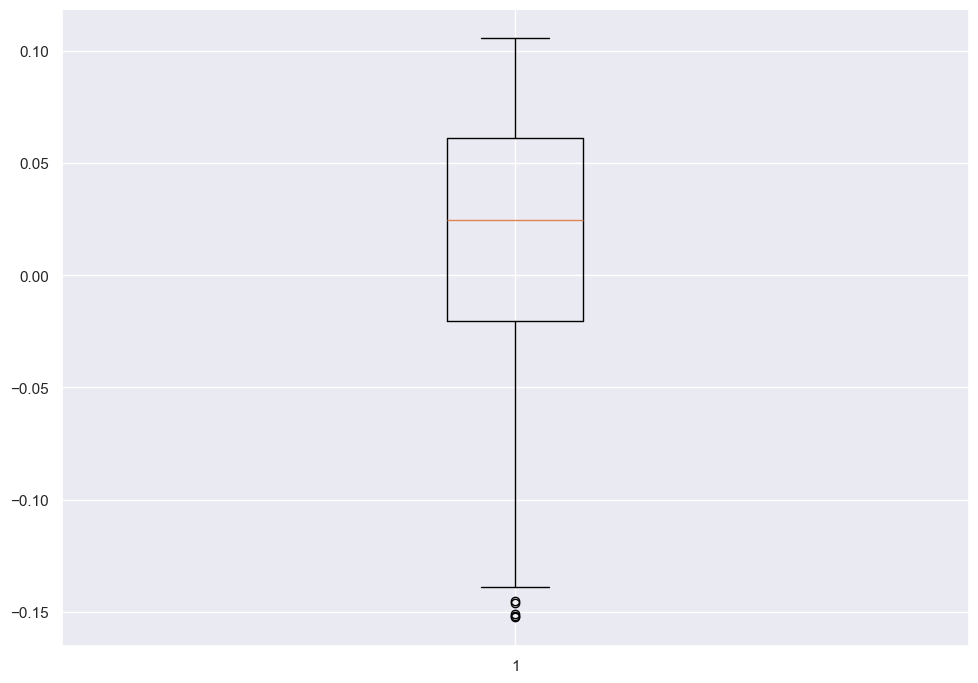

In [138]:
plt.boxplot(data['IF_scores'])

In [128]:
anomali_data_IF

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,IF_scores,IF_anomaly_score,anomaly_classification
3,52,1,1,0,1,183,93,0,0,2,28000,27.770313,-0.021780,-1,1
12,24,0,0,0,0,178,57,1,0,1,15000,17.990153,-0.021083,-1,-1
13,46,0,1,0,0,184,97,0,0,0,35000,28.650756,-0.006463,-1,1
14,18,0,0,1,0,150,76,0,0,1,15000,33.777778,-0.085071,-1,-1
16,42,0,0,0,1,149,67,0,0,0,30000,30.178821,-0.013212,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,40,0,1,1,0,171,74,0,0,0,38000,25.306932,-0.058168,-1,-1
986,26,0,0,0,0,182,120,0,0,0,43000,36.227509,-0.057141,-1,-1
987,24,1,1,1,0,163,103,1,0,1,24000,38.766984,-0.128784,-1,-1
988,62,1,0,1,1,171,94,1,0,1,17000,32.146643,-0.152203,-1,-1


## Problem : Since Isolation forest can't use the Silhouette Score as it is not an clustering algo. It has a different scoring methods. Overall the scores from Isolation forest and the previously discussed methods are not directly compareable.

# OneClassSVM

In [10]:
from sklearn.svm import OneClassSVM
model_svm = OneClassSVM(kernel='rbf', degree=5, gamma='scale', coef0=0.0, tol=0.001, nu=0.1, 
                       shrinking=True, cache_size=200, verbose=False, max_iter=- 1).fit(data[train_cols])
model_predictions_svm = model_svm.predict(data[train_cols])

In [15]:
data['svm_anomaly_scores'] = model_svm.decision_function(data[train_cols])  
svm_anomaly = data[data['svm_anomaly_scores'] < 0]

In [19]:
data[data['IF_anomaly_score']==-1][['IF_anomaly_score','svm_anomaly_scores']]

,IF_anomaly_score,svm_anomaly_scores
3,-1,6.524481
12,-1,-0.000019
13,-1,0.000158
14,-1,0.000025
16,-1,5.323264
...,...,...
980,-1,-4.601759
986,-1,-14.086943
987,-1,7.195209
988,-1,2.613593


## Problem : Since OneClassSVM can't use the Silhouette Score as it is not an clustering algo. It doesn't have a scoring mechanism without knowing the true labels and hence can't be fine tuned.

# Common Outliers 

In [59]:
l = [anomali_data_knn,anomali_data_kMeans,anomali_data_DBSCAN,anomali_data_HDBSCAN,anomali_data_IF]
# set.intersection(*map(set,l))
common_outliers = pd.concat(l, axis=1, join='inner').index
data.iloc[common_outliers][train_cols]

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI
213,46,0,0,0,0,170,111,0,1,1,22000,38.408304
295,64,1,1,0,1,163,91,0,0,2,40000,34.250442
333,43,1,1,0,1,179,63,0,0,1,18000,19.662308
788,30,0,0,1,0,158,81,0,1,1,27000,32.446723
978,40,0,1,1,0,168,70,0,0,0,17000,24.801587
986,26,0,0,0,0,182,120,0,0,0,43000,36.227509
988,62,1,0,1,1,171,94,1,0,1,17000,32.146643
989,45,1,0,1,0,160,100,1,0,1,10000,39.062500


In [60]:
anomali_data_DBSCAN = anomali_data_DBSCAN[['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'BMI','DBSCAN_Cluster', 'DBSCAN_outlier']]

In [61]:
anomali_data_kMeans = anomali_data_kMeans[['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants','AnyChronicDiseases',
                      'Height', 'Weight', 'KnownAllergies','HistoryOfCancerInFamily', 'NumberOfMajorSurgeries',
                        'PremiumPrice','BMI','KMeans_Cluster', 'Distance to Center']]

In [62]:
anomali_data_HDBSCAN = anomali_data_HDBSCAN[['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'BMI', 'HDBSCAN_cluster',
       'HDBSCAN_cluster_outlier_score']]

In [63]:
common_outliers = list(set(common_outliers))
common_outliers.append(987)
common_outliers.sort()

In [64]:
data.iloc[common_outliers][['HDBSCAN_cluster']]

,HDBSCAN_cluster
213,-1
295,-1
333,-1
788,-1
978,-1
986,-1
987,-1
988,-1
989,-1


In [65]:
common_outliers

[213, 295, 333, 788, 978, 986, 987, 988, 989]

# Failures 

## Isolation forest scoring 
-   The scoring techniques utilized by Isolation Forest differ from clustering algorithms, making direct comparison of scores between Isolation Forest and previously discussed methods challenging.
## Unable to use vanilla SVM
-   Vanilla SVM is an effective tool for anomaly detection, but its application is limited in this context due to its reliance on semi-supervised learning principles.
## OneClassSVM
-   OneClassSVM lacks the capability to utilize the Silhouette Score due to its non-applicability in clustering algorithms. Consequently, it lacks a scoring mechanism that operates without prior knowledge of true labels, impeding its ability to undergo fine-tuning.
## Removing Price and Age from training columns
-   Exclusion of 'Price' and 'Age' from the training columns significantly reduces the Silhouette Score across all methods, suggesting a heavy reliance on these variables for outlier prediction.   